# Project: Stock Analysis (AAPL vs MSFT)
**Objective:**
Download historical stock data, compute returns, volatility, correlation, beta, and implement a simple trading signal – all without look‑ahead bias.

**Dataset:**
Use yfinance to download daily data for AAPL and MSFT from 2020-01-01 to 2024-01-01.
Merge on date (inner join) and keep only the Close prices.



In [20]:
# Import Essential 
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Download aapl and msft stock's
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
msft = yf.download('MSFT', start='2020-01-01', end='2024-01-01')

# For simplicity using close column only
df_aapl = aapl["Close"].copy()
df_msft = msft["Close"].copy()

# Merging aapl and msft on the date time index
df = df_aapl.merge(df_msft,left_index=True, right_index=True, how='inner')
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,MSFT
Date,,
2020-01-02,72.333885,152.158401
2020-01-03,71.630638,150.263748
2020-01-06,72.201408,150.652176
2020-01-07,71.861862,149.278564
2020-01-08,73.017822,151.656326


In [21]:
df.info()
# No null values
# Datetime is index.


<class 'pandas.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1006 non-null   float64
 1   MSFT    1006 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


Here we have taken four years of data from 2020 to 2024. Total number of entries 1006 and no null values.

In [22]:
# Returns
df["log_return_aapl"] = np.log(df["AAPL"] / df["AAPL"].shift(1))
df["log_return_msft"] = np.log(df["MSFT"] / df["MSFT"].shift(1))
df["simple_return_aapl"] = df["AAPL"].pct_change()
df["simple_return_msft"] = df["MSFT"].pct_change()
df.head()

Ticker,AAPL,MSFT,log_return_aapl,log_return_msft,simple_return_aapl,simple_return_msft
Date,,,,,,
2020-01-02,72.333885,152.158401,NaN,NaN,NaN,NaN
2020-01-03,71.630638,150.263748,-0.009770,-0.012530,-0.009722,-0.012452
2020-01-06,72.201408,150.652176,0.007937,0.002582,0.007968,0.002585
2020-01-07,71.861862,149.278564,-0.004714,-0.009160,-0.004703,-0.009118
2020-01-08,73.017822,151.656326,0.015958,0.015803,0.016086,0.015928


Here, Simple returns are slightly higher than log returns for daily return calculation. The first row are NaN as there is no previous value to calculate them. `shift(1)` shifts the data one step backwards. 
What else should i add here like why log is prefered over simple? i forgot why, as simple are not accurate and log is prefereed?

Log returns have additive properties, they look at the difference in todays and tomorrows and shows the % change and keeps adding.

In [23]:
# Cumulative Performance for AAPL only
df["cum_simple"] = (1 + df["simple_return_aapl"]).cumprod() -1 
df["cum_log"] = df["log_return_aapl"].cumsum()

# for cum log to be equal to simple 
df["cum_log_to_simple"] = np.exp(df["cum_log"]) -1
df.head()

Ticker,AAPL,MSFT,log_return_aapl,log_return_msft,simple_return_aapl,simple_return_msft,cum_simple,cum_log,cum_log_to_simple
Date,,,,,,,,,
2020-01-02,72.333885,152.158401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630638,150.263748,-0.009770,-0.012530,-0.009722,-0.012452,-0.009722,-0.009770,-0.009722
2020-01-06,72.201408,150.652176,0.007937,0.002582,0.007968,0.002585,-0.001831,-0.001833,-0.001831
2020-01-07,71.861862,149.278564,-0.004714,-0.009160,-0.004703,-0.009118,-0.006526,-0.006547,-0.006526
2020-01-08,73.017822,151.656326,0.015958,0.015803,0.016086,0.015928,0.009455,0.009411,0.009455


In [24]:
# Rolling Volatility & Annualisation

# 20day rolling -> volatality
df["aapl_vol_20"] = df["log_return_aapl"].rolling(20).std()
df["msft_vol_20"] = df["log_return_msft"].rolling(20).std()
df.tail()

# Checking total count of null values
df.isna().sum()


Ticker
AAPL                   0
MSFT                   0
log_return_aapl        1
log_return_msft        1
simple_return_aapl     1
simple_return_msft     1
cum_simple             1
cum_log                1
cum_log_to_simple      1
aapl_vol_20           20
msft_vol_20           20
dtype: int64

> **20 day rolling:**
> This uses 20 days prices to measure next day volatality (std) which results in first 19 days NaN.
> First, we removed the NaN (first row) before calculating rolling. Else, first 20 days will be NaN.


In [25]:
# 50day rolling -> volatality
df["aapl_vol_50"] = df["log_return_aapl"].rolling(50).std()
df["msft_vol_50"] = df["log_return_msft"].rolling(50).std()
df.tail()

Ticker,AAPL,MSFT,log_return_aapl,log_return_msft,simple_return_aapl,simple_return_msft,cum_simple,cum_log,cum_log_to_simple,aapl_vol_20,msft_vol_20,aapl_vol_50,msft_vol_50
Date,,,,,,,,,,,,,
2023-12-22,191.433105,368.236572,-0.005563,0.002780,-0.005548,0.002784,1.646520,0.973246,1.646520,0.009045,0.009824,0.010378,0.012980
2023-12-26,190.889267,368.315308,-0.002845,0.000214,-0.002841,0.000214,1.639002,0.970401,1.639002,0.009075,0.009791,0.010258,0.012850
2023-12-27,190.988098,367.735260,0.000518,-0.001576,0.000518,-0.001575,1.640368,0.970918,1.640368,0.009059,0.009425,0.010254,0.012743
2023-12-28,191.413300,368.924805,0.002224,0.003230,0.002226,0.003235,1.646247,0.973142,1.646247,0.008946,0.009227,0.010143,0.012729
2023-12-29,190.375076,369.671936,-0.005439,0.002023,-0.005424,0.002025,1.631893,0.967704,1.631893,0.009050,0.009243,0.010110,0.012672


In [26]:
# Annualizing volatality on 20
# Its the daily return rolling 20 std, so anualizing with sqrt 252. 
df["ann_vol_20d"] = df["aapl_vol_20"] * np.sqrt(252)
df

Ticker,AAPL,MSFT,log_return_aapl,log_return_msft,simple_return_aapl,simple_return_msft,cum_simple,cum_log,cum_log_to_simple,aapl_vol_20,msft_vol_20,aapl_vol_50,msft_vol_50,ann_vol_20d
Date,,,,,,,,,,,,,,
2020-01-02,72.333885,152.158401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630638,150.263748,-0.009770,-0.012530,-0.009722,-0.012452,-0.009722,-0.009770,-0.009722,NaN,NaN,NaN,NaN,NaN
2020-01-06,72.201408,150.652176,0.007937,0.002582,0.007968,0.002585,-0.001831,-0.001833,-0.001831,NaN,NaN,NaN,NaN,NaN
2020-01-07,71.861862,149.278564,-0.004714,-0.009160,-0.004703,-0.009118,-0.006526,-0.006547,-0.006526,NaN,NaN,NaN,NaN,NaN
2020-01-08,73.017822,151.656326,0.015958,0.015803,0.016086,0.015928,0.009455,0.009411,0.009455,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,191.433105,368.236572,-0.005563,0.002780,-0.005548,0.002784,1.646520,0.973246,1.646520,0.009045,0.009824,0.010378,0.012980,0.143579
2023-12-26,190.889267,368.315308,-0.002845,0.000214,-0.002841,0.000214,1.639002,0.970401,1.639002,0.009075,0.009791,0.010258,0.012850,0.144068
2023-12-27,190.988098,367.735260,0.000518,-0.001576,0.000518,-0.001575,1.640368,0.970918,1.640368,0.009059,0.009425,0.010254,0.012743,0.143800


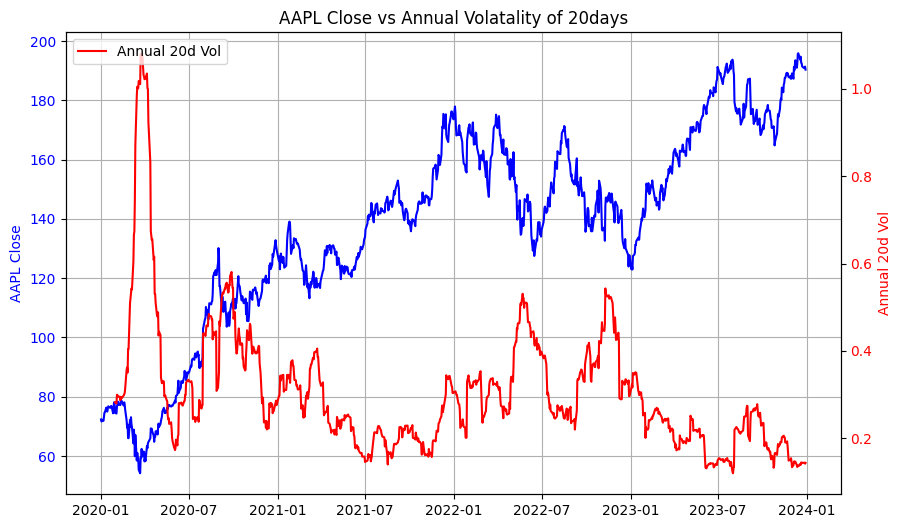

In [27]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(df.index,df["AAPL"], color = "Blue",label ="AAPL Close")
ax1.set_ylabel(ylabel = "AAPL Close", color = "Blue")
ax1.tick_params(axis="y", labelcolor="Blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df.index,df["ann_vol_20d"], color="Red",label="Annual 20d Vol")
ax2.set_ylabel(ylabel="Annual 20d Vol", color="Red")
ax2.tick_params(axis='y', labelcolor='red')

plt.title("AAPL Close vs Annual Volatality of 20days")
plt.legend(loc="upper left")
plt.show()

In certain events, we can see the spike of volatality.
1. in between Jan-July 2020, there is a huge spike. The spike in early 2020 is COVID‑19.
2. From mid of 2022 to 2023 we can see the spike and unstable market.

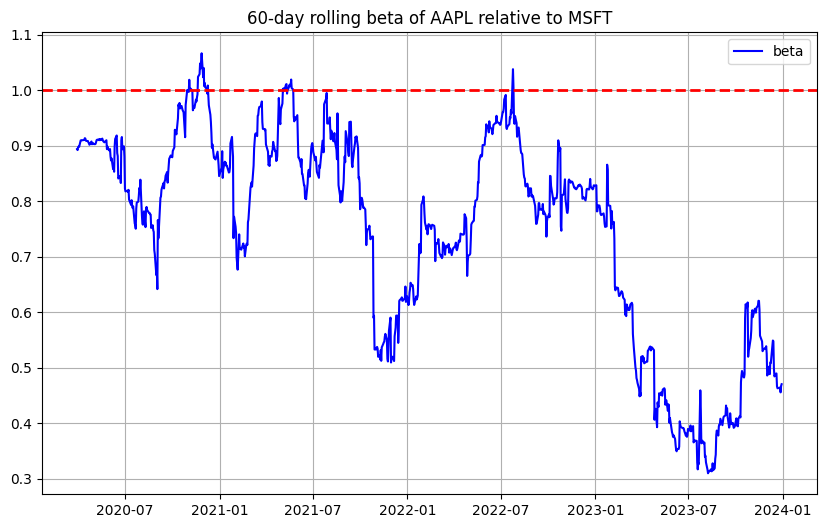

In [28]:
# Rolling Beta (Relative Risk)

# Compute 60‑day rolling covariance between AAPL and MSFT log returns.
rolling_60_cov = df["log_return_aapl"].rolling(60).cov(df["log_return_msft"])

# Compute 60‑day rolling variance of MSFT log returns.
rolling_60_var_msft = df["log_return_msft"].rolling(60).var()

# Compute beta = covariance / variance.
beta = rolling_60_cov / rolling_60_var_msft

# Plot beta over time. Add a horizontal line at y=1.
fig , ax = plt.subplots(figsize=(10,6))
ax.plot(beta.index, beta.values, color="Blue", label="beta")
ax.grid(True)

plt.axhline(y=1, color='r', linestyle='--', linewidth=2)
plt.title("60‑day rolling beta of AAPL relative to MSFT")
plt.legend()
plt.show()


Beta > 1 means AAPL is more sensitive to MSFT moves

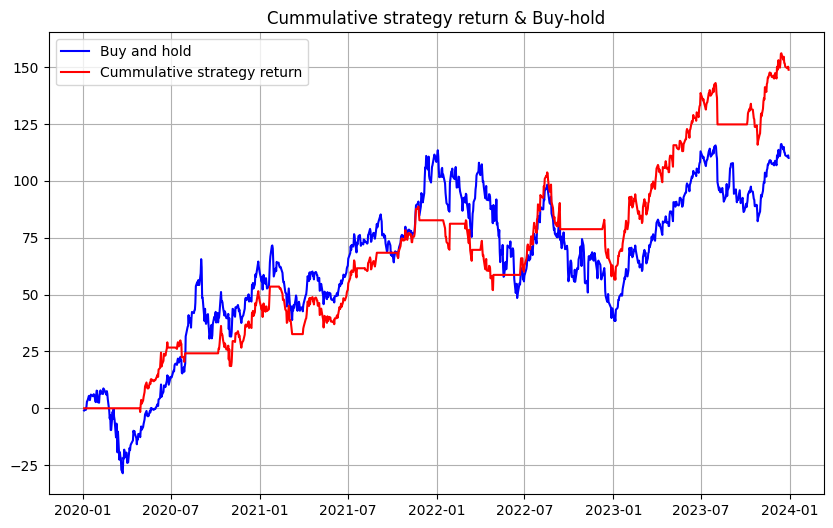

In [29]:
# Simple Trading Signal (Mean‑Reversion in Volatility)
# Using the same 20‑day rolling volatility (not annualised) for AAPL.
# aapl_vol_20 = df["aapl_vol_20"] or,
aapl_vol_20 = df["log_return_aapl"].rolling(20).std()

# Compute 60‑day rolling median of that volatility.
aapl_20_rolling_median = aapl_vol_20.rolling(60).median()

# Shift both by 1 day to avoid look‑ahead bias.
# Generate buy_signal = 1 if yesterday’s volatility < yesterday’s 60‑day median, else 0.
# (We don't shift here; we shift when we apply it to returns to simulate trading tomorrow)
buy_signal = (aapl_vol_20 < aapl_20_rolling_median).astype(int)

# Calculate hypothetical strategy returns:
# Shift the signal by 1 so today's return is multiplied by yesterday's signal.
strategy_return = buy_signal.shift(1) * df["log_return_aapl"]

# Compute cumulative strategy return and compare with buy‑and‑hold cumulative return.
cum_strategy_return = (1 + strategy_return).cumprod() -1
cum_buy_hold = (1 + df["log_return_aapl"]).cumprod() -1 

# Plot both cumulative returns on the same chart.
plt.figure(figsize=(10,6))
plt.plot(cum_buy_hold.index, cum_buy_hold * 100, label="Buy and hold" , color = "blue")
plt.plot(cum_strategy_return.index, cum_strategy_return * 100,  label = "Cummulative strategy return", color="red")

plt.title("Cummulative strategy return & Buy-hold")
plt.legend()
plt.grid(True)
plt.show()


### Volatility Mean-Reversion strategy on an asset like AAPL behaves like this:

**Why it might underperform:**

The "Cash" Problem: When volatility is higher than the 60-day median, your strategy returns 0. This means you go to cash and miss out on market rallies. If AAPL is in a strong bull market, sitting in cash hurts you because you miss the upward momentum.

High Volatility Bull Runs: Volatility often spikes during market crashes, but it also spikes during explosive upward breakouts. By forcing the strategy to only buy when volatility is low, you completely miss out on the stock's highest-growth days.

**Why it might outperform (or lower risk):**

*Smoother Ride:* While it might not make more total money than Buy-and-Hold, it often avoids major market crashes (since crashes happen during high-volatility environments where your strategy sits safely in cash). Your strategy might have a lower total return, but with much less risk and volatility.

The chart shows your strategy (red) outperforming buy-and-hold (blue) over the full period.

**Key observations:**

Final return:
Strategy ≈ 150–155
Buy & Hold ≈ 110–115

Drawdowns:
Buy-and-hold has deeper drops, especially:
1. early 2020
2. mid 2022
3. early 2023
Strategy avoids part of those declines.

Red flat sections:
Those horizontal periods likely mean: no position / cash holding strategy waiting for signal
That helped reduce downside volatility.

Tradeoff:
Strategy is smoother overall. But sometimes it lags during sharp rallies because it exits or waits.